### Routine to train and tabnet model

##### TODOs:
- Set MlFlow tracking URI
- Start mlflow server: mlflow server --host 127.0.0.1 --port 8080 (LOCAL)
- Change folders if needed

In [1]:

import os
import json
from datetime import datetime, timedelta
from pathlib import Path
from typing import Tuple, Optional, Union, List, Dict
from dataclasses import dataclass, field
import multiprocessing
import numpy as np
import pandas as pd
from shapely.geometry import Point
import seaborn as sns
from scipy.stats import skew, kurtosis, entropy, randint, uniform, loguniform
from scipy.fft import fft
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.calibration import calibration_curve
import xgboost as xgb
from xgboost import plot_importance
import joblib
from joblib import Parallel, delayed
import pyarrow as pa
from tqdm import tqdm
import mlflow
from mlflow.models.signature import infer_signature
# Remove duplicate imports and group standard, third-party, and project-specific imports

# Standard library

# Third-party libraries
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc,
    precision_recall_curve, average_precision_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

# Deep learning and specialized ML libraries
import xgboost as xgb
from sklearn.model_selection import (train_test_split, RandomizedSearchCV, 
                                   StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_curve, auc, precision_recall_curve,
                           average_precision_score, confusion_matrix, 
                           classification_report)
from scipy.stats import randint, uniform, loguniform
from xgboost import plot_importance
import joblib

import os
from datetime import datetime
import json

# MLflow imports
import mlflow
from mlflow.models.signature import infer_signature

from typing import Tuple, Optional, Union, List, Dict
from pathlib import Path
from dataclasses import dataclass, field
import multiprocessing
import os
import json
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
from shapely.geometry import Point
import seaborn as sns
from scipy.stats import skew, kurtosis, entropy, randint, uniform, loguniform
from scipy.fft import fft
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
import xgboost as xgb
from xgboost import plot_importance
import joblib
from joblib import Parallel, delayed
import pyarrow as pa
from tqdm import tqdm
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer


In [2]:
#! mlflow server --host 127.0.0.1 --port 8080

In [3]:
# Set MlFlow tracking URI
mlflow.set_tracking_uri("http://localhost:8080") # Check your MLflow server URI

In [4]:
RAW_DATA_TYPE = 'raw_counts'
FEATURES_TYPE = 'peak_enh'

In [5]:
@dataclass
class SampleConfig:
    """Sample configuration."""
    name: str
    n_samples_per_class: int
    random_state: int = 42

@dataclass
class DatasetInfo:
    n_samples: int
    n_features: int
    class_distribution: Dict[int, int]
    features_columns: List[str]
    labels_columns: List[str]

@dataclass
class DataLoader:
    features_path: Union[str, Path]
    labels_path: Union[str, Path]
    _features_df_cache: Optional[pd.DataFrame] = field(default=None, init=False, repr=False)
    _labels_df_cache: Optional[pd.DataFrame] = field(default=None, init=False, repr=False)

    def __post_init__(self):
        self.features_path = Path(self.features_path)
        self.labels_path = Path(self.labels_path)

        if not self.features_path.exists():
            raise FileNotFoundError(f"Features file not found: {self.features_path}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"Labels file not found: {self.labels_path}")

    def load_full_data(self, use_cache: bool = False) -> Tuple[pd.DataFrame, pd.DataFrame]:
        
        if use_cache and self._features_df_cache is not None and self._labels_df_cache is not None:
            return self._features_df_cache, self._labels_df_cache

        features_df = pd.read_parquet(self.features_path)
        labels_df = pd.read_parquet(self.labels_path)

        # Dimensions check
        if len(features_df) != len(labels_df):
            raise ValueError(f"Features and labels have different lengths: "
                           f"{len(features_df)} vs {len(labels_df)}")

        if use_cache:
            self._features_df_cache = features_df
            self._labels_df_cache = labels_df

        return features_df, labels_df

    def clear_cache(self) -> None:
        self._features_df_cache = None
        self._labels_df_cache = None

    def load_balanced_sample(self, 
                            n_samples_per_class: int, 
                            random_state: int = 42,
                            use_cache: bool = False) -> Tuple[pd.DataFrame, pd.DataFrame]:
        
        # Load full data (with caching option)
        features_df_full, labels_df_full = self.load_full_data(use_cache=use_cache)

        # Get sampled indices balanced across classes
        sampled_indices = self._get_balanced_indices(
            labels_df_full = labels_df_full,
            n_samples_per_class = n_samples_per_class,
            random_state =random_state
        )
        features_df = features_df_full.loc[sampled_indices].reset_index(drop=True)
        labels_df = labels_df_full.loc[sampled_indices].reset_index(drop=True)

        return features_df, labels_df

    def load_balanced_sample_memory_efficient(self, n_samples_per_class: int, 
                                            random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
        
        features_df_full = pd.read_parquet(self.features_path)
        labels_df_full = pd.read_parquet(self.labels_path)

        # Get sampled indices balanced across classes
        sampled_indices = self._get_balanced_indices(
            labels_df = labels_df_full, 
            n_samples_per_class = n_samples_per_class, 
            random_state = random_state
        )

        features_df = features_df_full.loc[sampled_indices].reset_index(drop=True)
        labels_df = labels_df_full.loc[sampled_indices].reset_index(drop=True)

        # Clean up memory
        del features_df_full, labels_df_full, sampled_indices

        return features_df, labels_df
    
    def _get_balanced_indices(self, labels_df: pd.DataFrame, 
                            n_samples_per_class: int, 
                            random_state: int = 42) -> pd.Index:
        """
        Get indices of a balanced sample from the labels DataFrame.
        """
        label_column = labels_df.iloc[:, 0]

        # Check if all classes have enough samples
        class_counts = label_column.value_counts()
        for class_label, count in class_counts.items():
            if count < n_samples_per_class:
                raise ValueError(f"Class {class_label} has only {count} samples, "
                               f"but {n_samples_per_class} requested")

        sampled_indices = (
            labels_df.groupby(label_column)
            .apply(lambda x: x.sample(n=n_samples_per_class, random_state=random_state))
            .index.get_level_values(1)
        )
        return sampled_indices

In [6]:
"""loader = DataLoader(
    features_path='processed_data/binary_classification/data_w_features/combined_features_q.parquet',
    labels_path='processed_data/binary_classification/data_w_features/labels_binary_q.parquet'
)

# Small balanced sample for hyperparameter tuning
features_df, labels_df = loader.load_balanced_sample_memory_efficient(n_samples_per_class=500000, random_state=42)
print(f"Training set shape: features={features_df.shape}, labels={labels_df.shape}")

# Large balanced sample for final retraining
features_df_to_finalize, labels_df_to_finalize = loader.load_balanced_sample_memory_efficient(
    n_samples_per_class=500000
)
print(f"Final set shape: features={features_df_to_finalize.shape}, labels={labels_df_to_finalize.shape}")
print(f"Class distribution in dev set set: {labels_df.iloc[:, 0].value_counts()}")
print(f"Class distribution in final set: {labels_df_to_finalize.iloc[:, 0].value_counts()}")"""

'loader = DataLoader(\n    features_path=\'processed_data/binary_classification/data_w_features/combined_features_q.parquet\',\n    labels_path=\'processed_data/binary_classification/data_w_features/labels_binary_q.parquet\'\n)\n\n# Small balanced sample for hyperparameter tuning\nfeatures_df, labels_df = loader.load_balanced_sample_memory_efficient(n_samples_per_class=500000, random_state=42)\nprint(f"Training set shape: features={features_df.shape}, labels={labels_df.shape}")\n\n# Large balanced sample for final retraining\nfeatures_df_to_finalize, labels_df_to_finalize = loader.load_balanced_sample_memory_efficient(\n    n_samples_per_class=500000\n)\nprint(f"Final set shape: features={features_df_to_finalize.shape}, labels={labels_df_to_finalize.shape}")\nprint(f"Class distribution in dev set set: {labels_df.iloc[:, 0].value_counts()}")\nprint(f"Class distribution in final set: {labels_df_to_finalize.iloc[:, 0].value_counts()}")'

In [7]:
import time

# Wait for 5 seconds
time.sleep(4*3600)

In [8]:
from collections import Counter
loader = DataLoader(
    features_path='processed_data/binary_classification/data_w_features/combined_features_q_peak_enh.parquet',
    labels_path='processed_data/binary_classification/data_w_features/labels_binary_q_peak_enh.parquet'
)

# Small balanced sample for hyperparameter tuning
features_df, labels_df = loader.load_balanced_sample_memory_efficient(n_samples_per_class=400000, random_state=42)
print(f"Training set shape: features={features_df.shape}, labels={labels_df.shape}")

# Large balanced sample for final retraining
features_df_to_finalize, labels_df_to_finalize = loader.load_balanced_sample_memory_efficient(
    n_samples_per_class=400000
)
print(f"Final set shape: features={features_df_to_finalize.shape}, labels={labels_df_to_finalize.shape}")
print(f"Class distribution in dev set set: {Counter(labels_df.iloc[:, 0])}")


Training set shape: features=(800000, 143), labels=(800000, 1)
Final set shape: features=(800000, 143), labels=(800000, 1)
Class distribution in dev set set: Counter({0: 400000, 1: 400000})


In [9]:
features_df.head()

,global_mean,global_std,global_min,global_max,global_median,global_range,global_skew,global_kurtosis,global_entropy,global_gini,...,ddm_q2_max,ddm_q2_energy,ddm_q3_mean,ddm_q3_std,ddm_q3_max,ddm_q3_energy,ddm_q4_mean,ddm_q4_std,ddm_q4_max,ddm_q4_energy
0,0.005,0.001490,0.003127,0.010758,0.004507,0.007631,1.492776,1.939331,5.258252,0.153520,...,0.010758,0.002095,0.004340,0.000991,0.008154,0.000793,0.004422,0.001196,0.009947,0.001259
1,0.005,0.000562,0.003785,0.006740,0.004931,0.002955,0.753503,0.696794,5.292130,0.061949,...,0.006740,0.001644,0.004758,0.000464,0.005616,0.000914,0.005035,0.000466,0.006641,0.001534
2,0.005,0.004349,0.002316,0.025841,0.003240,0.023525,2.695744,7.795244,5.036287,0.366232,...,0.025841,0.004592,0.003283,0.002023,0.011997,0.000595,0.004265,0.004361,0.024994,0.002233
3,0.005,0.009221,0.000816,0.053969,0.001110,0.053153,3.095943,10.171329,4.346050,0.677072,...,0.053969,0.009982,0.003267,0.005468,0.026917,0.001623,0.005186,0.010131,0.052843,0.007772
4,0.005,0.005198,0.000888,0.024135,0.002643,0.023247,1.598089,1.898304,4.853969,0.514708,...,0.024135,0.005927,0.002102,0.002364,0.012616,0.000400,0.002612,0.003470,0.018553,0.001132


In [10]:
from sklearn.model_selection import train_test_split

# Create a stratified subset (e.g., 10% of the data)
X_subset, _, y_subset, _ = train_test_split(
    features_df,
    labels_df,
    test_size=0.01,
    stratify=labels_df,
    random_state=42
)

# Reset index for convenience
X_subset = X_subset.reset_index(drop=True)
y_subset = y_subset.reset_index(drop=True)

In [11]:
X_subset

,global_mean,global_std,global_min,global_max,global_median,global_range,global_skew,global_kurtosis,global_entropy,global_gini,...,ddm_q2_max,ddm_q2_energy,ddm_q3_mean,ddm_q3_std,ddm_q3_max,ddm_q3_energy,ddm_q4_mean,ddm_q4_std,ddm_q4_max,ddm_q4_energy
0,0.005,0.004157,0.002165,0.020738,0.003074,0.018573,2.028797,3.435197,5.037986,0.377013,...,0.016366,0.002109,0.004423,0.003571,0.015203,0.001293,0.006156,0.005758,0.020738,0.004263
1,0.005,0.004974,0.001011,0.020236,0.002549,0.019225,1.373786,0.787192,4.879700,0.501114,...,0.018743,0.004309,0.003421,0.004270,0.019285,0.001197,0.003369,0.004172,0.018536,0.001726
2,0.005,0.000541,0.003415,0.006386,0.005002,0.002970,-0.267925,0.368486,5.292373,0.060011,...,0.006386,0.001663,0.005046,0.000411,0.006225,0.001025,0.004541,0.000497,0.005310,0.001252
3,0.005,0.003211,0.002258,0.015279,0.003878,0.013021,1.450801,1.355373,5.122179,0.327030,...,0.015279,0.003349,0.003267,0.001893,0.010887,0.000570,0.003244,0.001857,0.011696,0.000838
4,0.005,0.000908,0.003524,0.007620,0.004782,0.004096,0.714551,-0.313193,5.282336,0.101448,...,0.007620,0.001912,0.004338,0.000598,0.006568,0.000767,0.004559,0.000670,0.006902,0.001274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791995,0.005,0.006670,0.000786,0.032370,0.002090,0.031584,2.272343,4.727713,4.684474,0.580121,...,0.028785,0.004003,0.005021,0.007571,0.032370,0.003302,0.003180,0.005432,0.029141,0.002377
791996,0.005,0.005477,0.002019,0.033036,0.002967,0.031017,3.060235,9.889944,4.925384,0.421631,...,0.033036,0.006233,0.003281,0.002912,0.016864,0.000770,0.003885,0.004170,0.026348,0.001949
791997,0.005,0.000370,0.004484,0.006477,0.004892,0.001993,1.965683,3.895223,5.295697,0.035607,...,0.005320,0.001433,0.005108,0.000416,0.006232,0.001051,0.005163,0.000483,0.006477,0.001613
791998,0.005,0.003450,0.002372,0.017611,0.003415,0.015239,1.800140,2.508827,5.107931,0.328999,...,0.016781,0.002642,0.004232,0.002973,0.014141,0.001070,0.004899,0.004038,0.017611,0.002419


In [12]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Alternative approach using IQR-based method
def remove_outliers_iqr(X_subset, columns=None):
    if columns is None:
        columns = X_subset.select_dtypes(include=[np.number]).columns
    
    for col in columns:
        Q1 = X_subset[col].quantile(0.25)
        Q3 = X_subset[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        X_subset = X_subset[(X_subset[col] >= lower_bound) & (X_subset[col] <= upper_bound)]
    
    return X_subset

In [13]:
df = remove_outliers_iqr(X_subset=X_subset)

In [14]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope
from sklearn.svm import OneClassSVM

# Assuming X_subset is your feature data and y_subset is your binary labels

# Option 1: Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)  # 10% outliers
outlier_mask_iso = iso_forest.fit_predict(X_subset) == 1  # 1 for inliers, -1 for outliers

"""# Option 2: Elliptic Envelope (assumes Gaussian distribution)
elliptic = EllipticEnvelope(contamination=0.1, random_state=42)
outlier_mask_elliptic = elliptic.fit_predict(X_subset) == 1

# Option 3: One-Class SVM
svm = OneClassSVM(gamma='scale', nu=0.1)  # nu is roughly the fraction of outliers
outlier_mask_svm = svm.fit_predict(X_subset) == 1"""

# Apply the mask to both features and labels
X_filtered = X_subset[outlier_mask_iso]
y_filtered = y_subset[outlier_mask_iso]

In [15]:
X_filtered

,global_mean,global_std,global_min,global_max,global_median,global_range,global_skew,global_kurtosis,global_entropy,global_gini,...,ddm_q2_max,ddm_q2_energy,ddm_q3_mean,ddm_q3_std,ddm_q3_max,ddm_q3_energy,ddm_q4_mean,ddm_q4_std,ddm_q4_max,ddm_q4_energy
0,0.005,0.004157,0.002165,0.020738,0.003074,0.018573,2.028797,3.435197,5.037986,0.377013,...,0.016366,0.002109,0.004423,0.003571,0.015203,0.001293,0.006156,0.005758,0.020738,0.004263
2,0.005,0.000541,0.003415,0.006386,0.005002,0.002970,-0.267925,0.368486,5.292373,0.060011,...,0.006386,0.001663,0.005046,0.000411,0.006225,0.001025,0.004541,0.000497,0.005310,0.001252
3,0.005,0.003211,0.002258,0.015279,0.003878,0.013021,1.450801,1.355373,5.122179,0.327030,...,0.015279,0.003349,0.003267,0.001893,0.010887,0.000570,0.003244,0.001857,0.011696,0.000838
4,0.005,0.000908,0.003524,0.007620,0.004782,0.004096,0.714551,-0.313193,5.282336,0.101448,...,0.007620,0.001912,0.004338,0.000598,0.006568,0.000767,0.004559,0.000670,0.006902,0.001274
5,0.005,0.001518,0.003836,0.010852,0.004307,0.007016,1.997133,3.349090,5.258586,0.138920,...,0.010852,0.001783,0.004833,0.001403,0.009884,0.001013,0.004703,0.001422,0.010608,0.001449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791995,0.005,0.006670,0.000786,0.032370,0.002090,0.031584,2.272343,4.727713,4.684474,0.580121,...,0.028785,0.004003,0.005021,0.007571,0.032370,0.003302,0.003180,0.005432,0.029141,0.002377
791996,0.005,0.005477,0.002019,0.033036,0.002967,0.031017,3.060235,9.889944,4.925384,0.421631,...,0.033036,0.006233,0.003281,0.002912,0.016864,0.000770,0.003885,0.004170,0.026348,0.001949
791997,0.005,0.000370,0.004484,0.006477,0.004892,0.001993,1.965683,3.895223,5.295697,0.035607,...,0.005320,0.001433,0.005108,0.000416,0.006232,0.001051,0.005163,0.000483,0.006477,0.001613
791998,0.005,0.003450,0.002372,0.017611,0.003415,0.015239,1.800140,2.508827,5.107931,0.328999,...,0.016781,0.002642,0.004232,0.002973,0.014141,0.001070,0.004899,0.004038,0.017611,0.002419


In [16]:
FEATURES = X_subset.columns.tolist()

### Train tabnet

In [17]:
from sklearn.metrics import roc_auc_score
import test


class TabNetBinaryClassifier:
    """
    Class for training a TabNet binary classifier with GPU support
    """
    
    def __init__(self, 
                 X_original,
                 y_original,
                 n_d, 
                 n_a, 
                 n_steps, 
                 gamma,
                 n_independent=2,
                 n_shared=2,
                 lambda_sparse=1e-3,
                 optimizer_fn=torch.optim.Adam,
                 optimizer_params=dict(lr=1e-2),
                 mask_type='entmax',
                 scheduler_params=dict(step_size=50, gamma=0.9),
                 scheduler_fn=torch.optim.lr_scheduler.StepLR,
                 epsilon=1e-15,
                 device_name='auto'):
        """
        Initialize the TabNet classifier
        
        Parameters:
        -----------
        n_d : int
            Dimension of learned representations
        n_a : int 
            Dimension of attention
        n_steps : int
            Number of steps in feature selection
        gamma : float
            Coefficient for aggregated attention
        lambda_sparse : float
            Regularization coefficient for sparsity
        device_name : str
            'auto', 'cuda', 'cpu' or specific device ('cuda:0')
        """
        
        # Device configuration
        self.device = self._setup_device(device_name)
        print(f"Device used: {self.device}")
        
        self.tabnet_params = {
            'n_d': n_d,
            'n_a': n_a, 
            'n_steps': n_steps,
            'gamma': gamma,
            'n_independent': n_independent,
            'n_shared': n_shared,
            'lambda_sparse': lambda_sparse,
            'optimizer_fn': optimizer_fn,
            'optimizer_params': optimizer_params,
            'mask_type': mask_type,
            'scheduler_params': scheduler_params,
            'scheduler_fn': scheduler_fn,
            'epsilon': epsilon,
            'device_name': self.device
        }
        self.X_original = X_original
        self.y_original = y_original
        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.is_fitted = False
        
    def _setup_device(self, device_name):
        """
        Configure the computing device (CPU/GPU)
        """
        if device_name == 'auto':
            if torch.cuda.is_available():
                device = 'cuda'
                print(f"GPU available: {torch.cuda.get_device_name()}")
                print(f"GPU memory available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
            else:
                device = 'cpu'
                print("GPU not available, using CPU")
        else:
            device = device_name
            if device.startswith('cuda') and not torch.cuda.is_available():
                print("WARNING: GPU requested but not available, using CPU")
                device = 'cpu'
        
        return device
    
    def get_gpu_memory_info(self):
        """
        Returns GPU memory information
        """
        if torch.cuda.is_available() and self.device.startswith('cuda'):
            device_idx = 0 if self.device == 'cuda' else int(self.device.split(':')[1])
            allocated = torch.cuda.memory_allocated(device_idx) / 1e9
            reserved = torch.cuda.memory_reserved(device_idx) / 1e9
            total = torch.cuda.get_device_properties(device_idx).total_memory / 1e9
            
            print(f"GPU Memory:")
            print(f"  - Allocated: {allocated:.2f} GB")
            print(f"  - Reserved: {reserved:.2f} GB") 
            print(f"  - Total: {total:.2f} GB")
            print(f"  - Free: {total - reserved:.2f} GB")
            
            return {
                'allocated': allocated,
                'reserved': reserved,
                'total': total,
                'free': total - reserved
            }
        else:
            print("GPU memory not available")
            return None
    
    def clear_gpu_memory(self):
        """
        Clear GPU memory
        """
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print("GPU cache cleared")
    
    def prepare_data(self, X, y, test_size=0.2, random_state=42):
        """
        Prepare data for training
        
        Parameters:
        -----------
        df : pandas.DataFrame
            DataFrame with data
        target_col : str
            Name of target column
        test_size : float
            Proportion of test set
        random_state : int
            Seed for reproducibility
        scale_features : bool
            Whether to apply scaling to features
        """
        
        # Separate features and target
        X = self.X_original
        y = self.y_original

        # Save feature names
        self.feature_names = X.columns.tolist()
        
        # Convert to float32 to optimize GPU memory
        X = X.astype(np.float32)
        
        # Split X and y into train (64%), validation (16%), and test (20%) sets
        X_temp, X_test, y_temp, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            stratify=y,
            random_state=42
        )

        X_train, X_val, y_train, y_val = train_test_split(
            X_temp,
            y_temp,
            test_size=test_size,  # 0.2 * 0.8 = 0.16 of the original data
            stratify=y_temp,
            random_state=42
        )

        # Reset indices for convenience
        X_train = X_train.reset_index(drop=True)
        X_val = X_val.reset_index(drop=True)
        X_test = X_test.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
        y_val = y_val.reset_index(drop=True)
        y_test = y_test.reset_index(drop=True)

        # Numeric columns will be scaled by StandardScaler
        

        column_trans = ColumnTransformer(
            [ ('scaler',self.scaler, FEATURES),
            ], remainder='passthrough', n_jobs=4)

        train_X_transformed = column_trans.fit_transform(X_train, y_train)
        val_X_transformed = column_trans.transform(X_val )
        test_X_transformed = column_trans.transform(X_test)

        self.X_train = train_X_transformed
        self.X_val = val_X_transformed
        self.X_test = test_X_transformed

        # Convert to float32 for GPU
        self.X_train = X_train.values.astype(np.float32)
        self.y_train = y_train.values.astype(np.int64)

        self.X_test = X_test.values.astype(np.float32)
        self.y_test = y_test.values.astype(np.int64)

        self.X_val = X_val.values.astype(np.float32)
        self.y_val = y_val.values.astype(np.int64)

        # Remove infinite values from train, val, and test sets
        self.X_train = np.where(np.isinf(self.X_train), np.nan, self.X_train)
        self.X_val = np.where(np.isinf(self.X_val), np.nan, self.X_val)
        self.X_test = np.where(np.isinf(self.X_test), np.nan, self.X_test)

        print(f"Data prepared:")
        print(f"  - Training set: {self.X_train.shape}")
        print(f"  - Test set: {self.X_test.shape}")
        print(f"  - Validation set: {self.X_val.shape}")

        
        return self.X_train, self.X_test, self.y_train, self.y_test, self.X_val, self.y_val
    
    def train(self, 
              max_epochs=200, 
              patience=15, 
              batch_size=1024,
              virtual_batch_size=128,
              num_workers=0,
              drop_last=False):
        """
        Train the TabNet model
        
        Parameters:
        -----------
        max_epochs : int
            Maximum number of epochs
        patience : int
            Patience for early stopping
        batch_size : int
            Batch size
        virtual_batch_size : int
            Virtual batch size
        num_workers : int
            Number of workers for DataLoader (0 for GPU)
        """
        
        self.X_train, self.X_test, self.y_train, self.y_test, self.X_val, self.y_val = self.prepare_data(self.X_original, self.y_original, test_size=0.2, random_state=42)
        
        # Adapt batch_size for GPU
        if self.device.startswith('cuda'):
            gpu_memory = self.get_gpu_memory_info()
            if gpu_memory and gpu_memory['free'] < 2.0:  # Less than 2GB free
                suggested_batch_size = min(batch_size, 512)
                print(f"Limited GPU memory, reducing batch_size to {suggested_batch_size}")
                batch_size = suggested_batch_size
            
            # Optimize num_workers for GPU
            if num_workers == 0:
                num_workers = min(4, torch.cuda.device_count() * 2)
                
        print("Training configuration:")
        print(f"  - Device: {self.device}")
        print(f"  - Batch size: {batch_size}")
        print(f"  - Virtual batch size: {virtual_batch_size}")
        print(f"  - Num workers: {num_workers}")
        
        # Initialize model
        self.model = TabNetClassifier(**self.tabnet_params)
        
        # Check memory before training
        if self.device.startswith('cuda'):
            self.clear_gpu_memory()
            print("GPU memory before training:")
            self.get_gpu_memory_info()
        
        # Training
        print("\nStarting TabNet training...") 
        print(f"  - Training set: {self.X_train.shape}")
        print(f"  - Validation set: {self.X_val.shape}")
        print("NaN count in X_train:", np.isnan(self.X_train).sum())
        print("Inf count in X_train:", np.isinf(self.X_train).sum())
        print("NaN count in X_val:", np.isnan(self.X_val).sum())
        print("Inf count in X_val:", np.isinf(self.X_val).sum())
        #print(pd.DataFrame(self.X_train).describe())
        #print(pd.DataFrame(self.X_val).describe())
        
        # Remove infinite values from train, val, and test sets
        self.X_train = np.where(np.isinf(self.X_train), np.nan, self.X_train)
        self.X_val = np.where(np.isinf(self.X_val), np.nan, self.X_val)
        self.X_test = np.where(np.isinf(self.X_test), np.nan, self.X_test)


        try:
            self.model.fit(
                X_train=self.X_train,
                y_train=self.y_train.reshape(-1),
                eval_set=[(self.X_val, self.y_val.reshape(-1))],
                eval_name=['eval'],
                eval_metric=['accuracy', 'auc'],
                max_epochs=100,
                patience=patience,
                batch_size=512,
                virtual_batch_size=256,
                num_workers=num_workers,
                drop_last=drop_last,
            )
            
            self.is_fitted = True
            print("Training completed!")
            
            # Check memory after training
            if self.device.startswith('cuda'):
                print("\nGPU memory after training:")
                self.get_gpu_memory_info()
                
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("\nERROR: Insufficient GPU memory!")
                self.clear_gpu_memory()
            raise e
        
        return self.model
    
    def predict(self, X=None):
        """
        Make predictions
        """
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            
        # Convert to float32 for consistency
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float32)
        elif not isinstance(X, np.ndarray):
            X = np.array(X, dtype=np.float32)
        else:
            X = X.astype(np.float32)
            
        predictions = self.model.predict(X)
        return predictions
    
    def predict_proba(self, X=None):
        """
        Return prediction probabilities
        """
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            
        # Convert to float32 for consistency
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float32)
        elif not isinstance(X, np.ndarray):
            X = np.array(X, dtype=np.float32)
        else:
            X = X.astype(np.float32)
            
        probabilities = self.model.predict_proba(X)
        return probabilities
    
    def evaluate(self, X=None, y=None, plot_results=True):
        """
        Evaluate model performance
        """
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            y = self.y_test
        
        # Predictions
        y_pred = self.predict(X)
        y_pred_proba = self.predict_proba(X)
        
        # Metrics
        accuracy = accuracy_score(y, y_pred)
        auc_score = roc_auc_score(y, y_pred_proba[:, 1])
        
        print(f"\n=== EVALUATION RESULTS ===")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"AUC Score: {auc_score:.4f}")
        print(f"\nClassification Report:")
        print(classification_report(y, y_pred))
        

        if plot_results:
            
            self.plot_results(y, y_pred, y_pred_proba[:, 1])
        return {
            'accuracy': accuracy,
            'auc_score': auc_score,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
    
    def plot_results(self, y_true, y_pred, y_pred_proba):
        """
        Visualize results
        """
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        
        # ROC Curve
        from sklearn.metrics import roc_auc_score, roc_curve
       
        fpr, tpr, _ = roc_curve(self.y_test.ravel(), y_pred_proba)
        auc = roc_auc_score(self.y_test.ravel(), y_pred_proba)
        
        axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
        axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('ROC Curve')
        axes[1].legend()
        axes[1].grid(True)
        

        # Distribution of Probabilities
        axes[2].hist(y_pred_proba[self.y_test.ravel() == 0], bins=30, alpha=0.7, label='Class 0', color='red')
        axes[2].hist(y_pred_proba[self.y_test.ravel() == 1], bins=30, alpha=0.7, label='Class 1', color='blue')
        axes[2].set_xlabel('Predicted Probability')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title('Distribution of Predicted Probabilities')
        axes[2].legend()
        axes[2].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def plot_feature_importance(self, plot=True, max_features=20):
        try:
            self.model.plot_feature_importance(max_features=max_features)
            plt.title("Feature Importance")
            plt.show()
        except Exception as e:
            print(f"Error plotting feature importance: {e}")

    def save_model(self, filepath):
        """
        Save the model
        """
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        self.model.save_model(filepath)
        print(f"Model saved at: {filepath}")
    
    def load_model(self, filepath):
        """
        Load a saved model
        """
        self.model = TabNetClassifier(device_name=self.device)
        self.model.load_model(filepath)
        self.is_fitted = True
        print(f"Model loaded from: {filepath}")
    
    def get_model_summary(self):
        """
        Return model and hardware summary
        """
        if not self.is_fitted:
            print("Model not yet trained")
            return
        
        print(f"\n=== MODEL SUMMARY ===")
        print(f"Device: {self.device}")
        print(f"TabNet Parameters:")
        for key, value in self.tabnet_params.items():
            if key != 'device_name':
                print(f"  - {key}: {value}")
        
        if hasattr(self.model, 'network'):
            total_params = sum(p.numel() for p in self.model.network.parameters())
            trainable_params = sum(p.numel() for p in self.model.network.parameters() if p.requires_grad)
            print(f"Total parameters: {total_params:,}")
            print(f"Trainable parameters: {trainable_params:,}")
        
        if self.device.startswith('cuda'):
            self.get_gpu_memory_info()

In [18]:
"""=== OPTIMIZATION COMPLETED ===
Best auc: 0.9657
Best parameters:
  - n_d: 77
  - n_a: 110
  - n_steps: 8
  - gamma: 1.9067107319494947
  - n_independent: 1
  - n_shared: 5
  - lambda_sparse: 0.0005807365274596347
  - lr: 0.003944458659837453
  - step_size: 31
  - scheduler_gamma: 0.953213126517786
  - batch_size: 512
  - virtual_batch_size: 128
  """

'=== OPTIMIZATION COMPLETED ===\nBest auc: 0.9657\nBest parameters:\n  - n_d: 77\n  - n_a: 110\n  - n_steps: 8\n  - gamma: 1.9067107319494947\n  - n_independent: 1\n  - n_shared: 5\n  - lambda_sparse: 0.0005807365274596347\n  - lr: 0.003944458659837453\n  - step_size: 31\n  - scheduler_gamma: 0.953213126517786\n  - batch_size: 512\n  - virtual_batch_size: 128\n  '

In [19]:
X_subset.describe()

,global_mean,global_std,global_min,global_max,global_median,global_range,global_skew,global_kurtosis,global_entropy,global_gini,...,ddm_q2_max,ddm_q2_energy,ddm_q3_mean,ddm_q3_std,ddm_q3_max,ddm_q3_energy,ddm_q4_mean,ddm_q4_std,ddm_q4_max,ddm_q4_energy
count,7.920000e+05,792000.000000,7.920000e+05,792000.000000,792000.000000,792000.000000,792000.000000,792000.000000,792000.000000,792000.000000,...,7.920000e+05,7.920000e+05,7.920000e+05,792000.000000,7.920000e+05,7.920000e+05,7.920000e+05,792000.000000,7.920000e+05,7.920000e+05
mean,5.000000e-03,0.002236,3.183567e-03,0.014627,0.004128,0.011444,1.657304,3.748826,5.161091,0.197749,...,1.350206e-02,2.586739e-03,4.366775e-03,0.001413,9.609983e-03,9.714898e-04,4.750222e-03,0.002146,1.315325e-02,2.002476e-03
std,4.432922e-18,0.002194,1.156973e-03,0.010344,0.001007,0.011371,1.021979,3.760729,0.202596,0.181976,...,9.538422e-03,1.733633e-03,8.342544e-04,0.001589,6.139143e-03,4.687336e-04,8.793482e-04,0.002330,9.518805e-03,1.461381e-03
min,5.000000e-03,0.000096,1.434119e-20,0.005215,0.000830,0.000496,-1.271623,-1.995862,4.166318,0.010778,...,1.434119e-20,1.234019e-38,1.480723e-20,0.000000,1.480723e-20,8.770166e-39,1.480723e-20,0.000000,1.480723e-20,1.315525e-38
25%,5.000000e-03,0.000495,2.447701e-03,0.006572,0.003511,0.002605,0.811003,0.634014,5.103867,0.053831,...,6.183499e-03,1.538988e-03,4.016348e-03,0.000342,5.571842e-03,8.005073e-04,4.458223e-03,0.000435,6.063512e-03,1.405008e-03
50%,5.000000e-03,0.001271,3.500812e-03,0.010174,0.004586,0.006663,1.776258,2.846231,5.269822,0.119958,...,9.347750e-03,1.784742e-03,4.659331e-03,0.000692,6.784981e-03,9.415996e-04,4.906846e-03,0.001102,8.952788e-03,1.529273e-03
75%,5.000000e-03,0.003621,4.091686e-03,0.020506,0.004935,0.018185,2.404771,5.920730,5.293498,0.317133,...,1.846638e-02,2.814220e-03,4.944839e-03,0.002060,1.174190e-02,1.022624e-03,5.090492e-03,0.003332,1.778671e-02,1.929515e-03
max,5.000000e-03,0.011526,4.776928e-03,0.086437,0.005361,0.084644,7.220591,61.590269,5.298134,0.724511,...,6.885997e-02,2.561864e-02,1.350382e-02,0.017838,8.214819e-02,1.780761e-02,1.167298e-02,0.019762,8.643705e-02,3.071394e-02


In [20]:
y_subset

,0
0,0
1,0
2,1
3,0
4,1
...,...
791995,0
791996,0
791997,1
791998,0


In [21]:

classifier = TabNetBinaryClassifier(
    X_original=X_subset,
    y_original=y_subset,
    n_d=77,
    n_a=110, 
    n_steps=8,
    gamma=1.9067107319494947,
    lambda_sparse=0.0005807365274596347,
    optimizer_params=dict(lr=0.003944458659837453),
    scheduler_params=dict(step_size=31, gamma=0.953213126517786),

device_name='auto'  # Automatically detect GPU
)

# Show GPU info
classifier.get_gpu_memory_info()

# Train model 
model = classifier.train(
    max_epochs=100, 
    patience=20, 
    batch_size=512,  # Larger batch size for GPU
    virtual_batch_size=256,
    num_workers=4  # Parallel data loading
)


GPU available: NVIDIA RTX A500 Laptop GPU
GPU memory available: 4.3 GB
Device used: cuda
GPU Memory:
  - Allocated: 0.00 GB
  - Reserved: 0.00 GB
  - Total: 4.29 GB
  - Free: 4.29 GB
Data prepared:
  - Training set: (506880, 143)
  - Test set: (158400, 143)
  - Validation set: (126720, 143)
GPU Memory:
  - Allocated: 0.00 GB
  - Reserved: 0.00 GB
  - Total: 4.29 GB
  - Free: 4.29 GB
Training configuration:
  - Device: cuda
  - Batch size: 512
  - Virtual batch size: 256
  - Num workers: 4
GPU cache cleared
GPU memory before training:
GPU Memory:
  - Allocated: 0.00 GB
  - Reserved: 0.00 GB
  - Total: 4.29 GB
  - Free: 4.29 GB

Starting TabNet training...
  - Training set: (506880, 143)
  - Validation set: (126720, 143)
NaN count in X_train: 0
Inf count in X_train: 0


c:\Users\alessandro.togni\AppData\Local\anaconda3\envs\great_geo_k\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


NaN count in X_val: 0
Inf count in X_val: 0
epoch 0  | loss: 0.46593 | eval_accuracy: 0.83553 | eval_auc: 0.92338 |  0:01:53s
epoch 1  | loss: 0.3079  | eval_accuracy: 0.87593 | eval_auc: 0.9467  |  0:03:49s
epoch 2  | loss: 0.29448 | eval_accuracy: 0.88566 | eval_auc: 0.95144 |  0:05:44s
epoch 3  | loss: 0.27767 | eval_accuracy: 0.88189 | eval_auc: 0.95124 |  0:07:37s
epoch 4  | loss: 0.26807 | eval_accuracy: 0.89685 | eval_auc: 0.96046 |  0:09:34s
epoch 5  | loss: 0.26308 | eval_accuracy: 0.89786 | eval_auc: 0.96078 |  0:11:28s
epoch 6  | loss: 0.25361 | eval_accuracy: 0.89462 | eval_auc: 0.959   |  0:13:20s
epoch 7  | loss: 0.2527  | eval_accuracy: 0.89693 | eval_auc: 0.96179 |  0:15:10s
epoch 8  | loss: 0.24933 | eval_accuracy: 0.89872 | eval_auc: 0.96146 |  0:17:05s
epoch 9  | loss: 0.25196 | eval_accuracy: 0.89865 | eval_auc: 0.96257 |  0:19:00s
epoch 10 | loss: 0.24708 | eval_accuracy: 0.90077 | eval_auc: 0.96449 |  0:20:54s
epoch 11 | loss: 0.24442 | eval_accuracy: 0.90234 | ev

c:\Users\alessandro.togni\AppData\Local\anaconda3\envs\great_geo_k\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed!

GPU memory after training:
GPU Memory:
  - Allocated: 0.05 GB
  - Reserved: 0.28 GB
  - Total: 4.29 GB
  - Free: 4.02 GB


<Axes: >

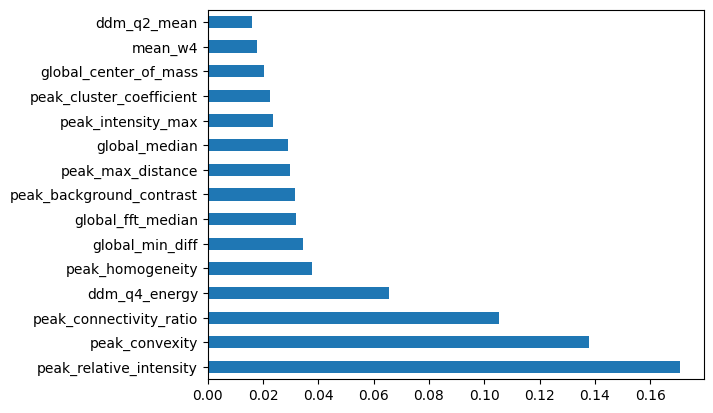

In [22]:
feat_importances = pd.Series(classifier.model.feature_importances_, index=X_subset.columns)
feat_importances.nlargest(15).plot(kind='barh')


=== EVALUATION RESULTS ===
Accuracy: 0.9124
AUC Score: 0.9717

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     79200
           1       0.92      0.91      0.91     79200

    accuracy                           0.91    158400
   macro avg       0.91      0.91      0.91    158400
weighted avg       0.91      0.91      0.91    158400



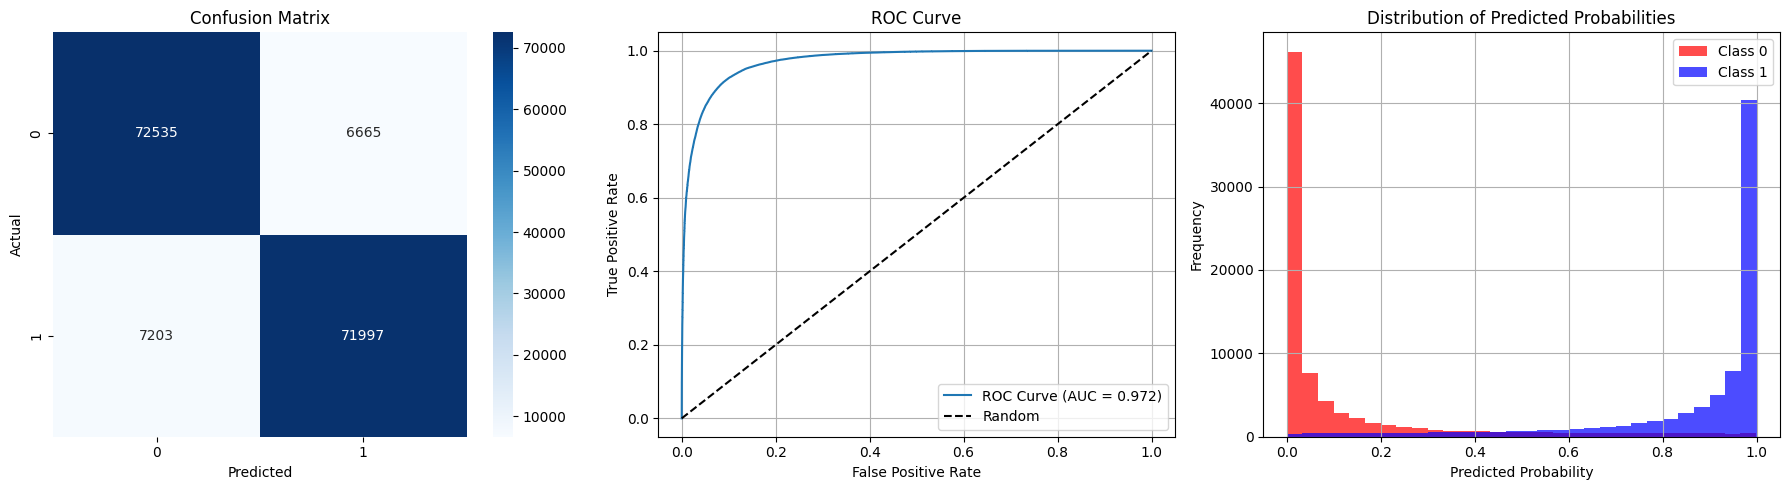

Error plotting feature importance: 'TabNetClassifier' object has no attribute 'plot_feature_importance'


In [23]:
# Evaluate performance
results = classifier.evaluate()
    
classifier.plot_feature_importance(plot=True, max_features=20)

In [24]:
# Show model summary
classifier.get_model_summary()

# Save model
classifier.save_model(f'tabnet_binary_{RAW_DATA_TYPE}_{FEATURES_TYPE}.zip')

# Clear GPU memory
classifier.clear_gpu_memory()


=== MODEL SUMMARY ===
Device: cuda
TabNet Parameters:
  - n_d: 77
  - n_a: 110
  - n_steps: 8
  - gamma: 1.9067107319494947
  - n_independent: 2
  - n_shared: 2
  - lambda_sparse: 0.0005807365274596347
  - optimizer_fn: <class 'torch.optim.adam.Adam'>
  - optimizer_params: {'lr': 0.003944458659837453}
  - mask_type: entmax
  - scheduler_params: {'step_size': 31, 'gamma': 0.953213126517786}
  - scheduler_fn: <class 'torch.optim.lr_scheduler.StepLR'>
  - epsilon: 1e-15
Total parameters: 1,538,086
Trainable parameters: 1,538,086
GPU Memory:
  - Allocated: 0.05 GB
  - Reserved: 0.29 GB
  - Total: 4.29 GB
  - Free: 4.01 GB
Successfully saved model at tabnet_binary_raw_counts_peak_enh.zip.zip
Model saved at: tabnet_binary_raw_counts_peak_enh.zip
GPU cache cleared


## Hyperparameters search with optuna

In [25]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, accuracy_score

class TabNetBinaryClassifierOptuna:
    """
    Class for training a TabNet binary classifier with GPU support and Optuna hyperparameter optimization
    """
    
    def __init__(self,
                 X_original=None,
                 y_original=None,
                 n_d=32,
                 n_a=32,
                 n_steps=5,
                 gamma=1.3,
                 n_independent=2,
                 n_shared=2,
                 lambda_sparse=1e-3,
                 optimizer_fn=torch.optim.Adam,
                 optimizer_params=dict(lr=1e-2),
                 mask_type='entmax',
                 scheduler_params=dict(step_size=50, gamma=0.9),
                 scheduler_fn=torch.optim.lr_scheduler.StepLR,
                 epsilon=1e-15,
                 device_name='auto'):
        """
        Initialize the TabNet classifier
        
        Parameters:
        -----------
        n_d : int
            Dimension of learned representations
        n_a : int 
            Dimension of attention
        n_steps : int
            Number of steps in feature selection
        gamma : float
            Coefficient for aggregated attention
        lambda_sparse : float
            Regularization coefficient for sparsity
        device_name : str
            'auto', 'cuda', 'cpu' or specific device ('cuda:0')
        """
        
        # Device configuration
        self.device = self._setup_device(device_name)
        print(f"Device used: {self.device}")
        
        self.tabnet_params = {
            'n_d': n_d,
            'n_a': n_a, 
            'n_steps': n_steps,
            'gamma': gamma,
            'n_independent': n_independent,
            'n_shared': n_shared,
            'lambda_sparse': lambda_sparse,
            'optimizer_fn': optimizer_fn,
            'optimizer_params': optimizer_params,
            'mask_type': mask_type,
            'scheduler_params': scheduler_params,
            'scheduler_fn': scheduler_fn,
            'epsilon': epsilon,
            'device_name': self.device
        }
        
        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.is_fitted = False
        self.best_params = None
        self.study = None
        self.X_original = X_original
        self.y_original = y_original

    def _setup_device(self, device_name):
        """
        Configure the computing device (CPU/GPU)
        """
        if device_name == 'auto':
            if torch.cuda.is_available():
                device = 'cuda'
                print(f"GPU available: {torch.cuda.get_device_name()}")
                print(f"GPU memory available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
            else:
                device = 'cpu'
                print("GPU not available, using CPU")
        else:
            device = device_name
            if device.startswith('cuda') and not torch.cuda.is_available():
                print("WARNING: GPU requested but not available, using CPU")
                device = 'cpu'
        
        return device
    
    def get_gpu_memory_info(self):
        """
        Returns GPU memory information
        """
        if torch.cuda.is_available() and self.device.startswith('cuda'):
            device_idx = 0 if self.device == 'cuda' else int(self.device.split(':')[1])
            allocated = torch.cuda.memory_allocated(device_idx) / 1e9
            reserved = torch.cuda.memory_reserved(device_idx) / 1e9
            total = torch.cuda.get_device_properties(device_idx).total_memory / 1e9
            
            print(f"GPU Memory:")
            print(f"  - Allocated: {allocated:.2f} GB")
            print(f"  - Reserved: {reserved:.2f} GB") 
            print(f"  - Total: {total:.2f} GB")
            print(f"  - Free: {total - reserved:.2f} GB")
            
            return {
                'allocated': allocated,
                'reserved': reserved,
                'total': total,
                'free': total - reserved
            }
        else:
            print("GPU memory not available")
            return None
    
    def clear_gpu_memory(self):
        """
        Clear GPU memory
        """
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print("GPU cache cleared")
    
    def prepare_data(self, X, y, target_col='y', test_size=0.2, random_state=42, scale_features=True):
        """
        Prepare data for training
        
        Parameters:
        -----------
        df : pandas.DataFrame
            DataFrame with data
        target_col : str
            Name of target column
        test_size : float
            Proportion of test set
        random_state : int
            Seed for reproducibility
        scale_features : bool
            Whether to apply scaling to features
        """
        
        X = self.X_original
        y = self.y_original

        # Save feature names
        self.feature_names = X.columns.tolist()
        
        # Convert to float32 to optimize GPU memory
        X = X.astype(np.float32)
        
        # Split X and y into train (64%), validation (16%), and test (20%) sets
        X_temp, X_test, y_temp, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            stratify=y,
            random_state=42
        )

        X_train, X_val, y_train, y_val = train_test_split(
            X_temp,
            y_temp,
            test_size=0.2,  # 0.2 * 0.8 = 0.16 of the original data
            stratify=y_temp,
            random_state=42
        )

        # Reset indices for convenience
        X_train = X_train.reset_index(drop=True)
        X_val = X_val.reset_index(drop=True)
        X_test = X_test.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
        y_val = y_val.reset_index(drop=True)
        y_test = y_test.reset_index(drop=True)

        # Numeric columns will be scaled by StandardScaler
        scaler = StandardScaler()

        

        column_trans = ColumnTransformer(
            [ ('scaler',scaler, FEATURES),
            ], remainder='passthrough', n_jobs=4)

        train_X_transformed = column_trans.fit_transform(X_train, y_train)
        val_X_transformed = column_trans.transform(X_val )
        test_X_transformed = column_trans.transform(X_test)

        self.X_train = train_X_transformed
        self.X_val = val_X_transformed
        self.X_test = test_X_transformed

        # Convert to float32 for GPU
        self.X_train = X_train.values.astype(np.float32)
        self.y_train = y_train.values.astype(np.int64)

        self.X_test = X_test.values.astype(np.float32)
        self.y_test = y_test.values.astype(np.int64)

        self.X_val = X_val.values.astype(np.float32)
        self.y_val = y_val.values.astype(np.int64)

        print("Data prepared:")
        print(f"  - Training set: {self.X_train.shape}")
        print(f"  - Test set: {self.X_test.shape}")
        print(f"  - Validation set: {self.X_val.shape}")

        
        return self.X_train, self.X_test, self.y_train, self.y_test, self.X_val, self.y_val

    def optimize_hyperparameters(self, 
                                n_trials=50,
                                study_name=None,
                                metric='auc',
                                direction='maximize',
                                pruning=True,
                                n_jobs=-1,
                                timeout=None,
                                max_epochs_optuna=50,
                                patience_optuna=10):
        """
        Optimize hyperparameters using Optuna
        
        Parameters:
        -----------
        n_trials : int
            Number of optimization trials
        study_name : str
            Name for the study (optional)
        metric : str
            Metric to optimize ('auc' or 'accuracy')
        direction : str
            'maximize' or 'minimize'
        pruning : bool
            Whether to use pruning for early trial termination
        n_jobs : int
            Number of parallel jobs (1 for sequential)
        timeout : int
            Time limit in seconds (None for no limit)
        max_epochs_optuna : int
            Max epochs for each trial (reduced for faster optimization)
        patience_optuna : int
            Patience for each trial (reduced for faster optimization)
        """

        self.X_train, self.X_test, self.y_train, self.y_test, self.X_val, self.y_val = self.prepare_data(self.X_original, self.y_original, test_size=0.2, random_state=42)

        print("\n=== STARTING HYPERPARAMETER OPTIMIZATION ===")
        print(f"Trials: {n_trials}")
        print(f"Metric: {metric}")
        print(f"Direction: {direction}")
        print(f"Max epochs per trial: {max_epochs_optuna}")
        
        def objective(trial):
            """
            Objective function for Optuna optimization
            """
            
            # Suggest hyperparameters
            params = {
                'n_d': trial.suggest_int('n_d', 8, 128),
                'n_a': trial.suggest_int('n_a', 8, 128),
                'n_steps': trial.suggest_int('n_steps', 3, 10),
                'gamma': trial.suggest_float('gamma', 1.0, 2.0),
                'n_independent': trial.suggest_int('n_independent', 1, 5),
                'n_shared': trial.suggest_int('n_shared', 1, 5),
                'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-6, 1e-1, log=True),
                'optimizer_fn': torch.optim.Adam,
                'optimizer_params': {
                    'lr': trial.suggest_float('lr', 1e-5, 1e-1, log=True)
                },
                'mask_type': 'entmax',
                'scheduler_params': {
                    'step_size': trial.suggest_int('step_size', 10, 100),
                    'gamma': trial.suggest_float('scheduler_gamma', 0.8, 0.99)
                },
                'scheduler_fn': torch.optim.lr_scheduler.StepLR,
                'epsilon': 1e-15,
                'device_name': self.device
            }
            
            # Training parameters
            batch_size = trial.suggest_categorical('batch_size', [256, 512, 1024, 2048])
            virtual_batch_size = trial.suggest_categorical('virtual_batch_size', [64, 128, 256])
            
            # Create temporary model
            temp_model = TabNetClassifier(**params)
            
            try:
                # Clear GPU memory before each trial
                #if self.device.startswith('cuda'):
                #    self.clear_gpu_memory()
                
                # Train model
                temp_model.fit(
                    X_train=self.X_train,
                    y_train=self.y_train.reshape(-1),
                    eval_set=[(self.X_val, self.y_val.reshape(-1))],
                    eval_name=['val'],
                    eval_metric=['accuracy', 'auc'],
                    max_epochs=max_epochs_optuna,
                    patience=patience_optuna,
                    batch_size=batch_size,
                    virtual_batch_size=virtual_batch_size,
                    num_workers=0,
                    drop_last=False
                )
                
                # Make predictions on validation set
                y_pred_proba = temp_model.predict_proba(self.X_val)
                y_pred = temp_model.predict(self.X_val)
                
                # Calculate metrics
                if metric == 'auc':
                    score = roc_auc_score(self.y_val, y_pred_proba[:, 1])
                elif metric == 'accuracy':
                    score = accuracy_score(self.y_val, y_pred)
                else:
                    raise ValueError(f"Unsupported metric: {metric}")
                
                # Report intermediate values for pruning
                trial.report(score, step=max_epochs_optuna)
                
                # Handle pruning
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
                
                return score
                
            except Exception as e:
                print(f"Trial failed: {str(e)}")
                # Return worst possible score for failed trials
                return 0.0 if direction == 'maximize' else float('inf')
            
            finally:
                # Clean up memory
                del temp_model
                if self.device.startswith('cuda'):
                    self.clear_gpu_memory()
        
        # Create study
        sampler = TPESampler(seed=42)
        pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10) if pruning else None
        
        study_name = study_name or f"tabnet_optimization_{metric}"
        self.study = optuna.create_study(
            direction=direction,
            sampler=sampler,
            pruner=pruner,
            study_name=study_name
        )
        
        # Run optimization
        print("\nRunning optimization...")
        self.study.optimize(
            objective, 
            n_trials=n_trials,
            n_jobs=n_jobs,
            timeout=timeout,
            show_progress_bar=True
        )
        
        # Store best parameters
        self.best_params = self.study.best_params.copy()
        
        # Print results
        print(f"\n=== OPTIMIZATION COMPLETED ===")
        print(f"Best {metric}: {self.study.best_value:.4f}")
        print(f"Best parameters:")
        for key, value in self.best_params.items():
            print(f"  - {key}: {value}")
        
        print(f"\nOptimization statistics:")
        print(f"  - Total trials: {len(self.study.trials)}")
        print(f"  - Completed trials: {len([t for t in self.study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
        print(f"  - Pruned trials: {len([t for t in self.study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
        print(f"  - Failed trials: {len([t for t in self.study.trials if t.state == optuna.trial.TrialState.FAIL])}")
        
        return self.study
    
    def train_with_best_params(self, 
                              max_epochs=200, 
                              patience=15,
                              num_workers=0,
                              drop_last=False):
        """
        Train model with best parameters found by Optuna
        """
        if self.best_params is None:
            raise ValueError("You must first run optimize_hyperparameters()")
        
        print(f"\n=== TRAINING WITH BEST PARAMETERS ===")
        
        # Extract training parameters
        batch_size = self.best_params.pop('batch_size', 1024)
        virtual_batch_size = self.best_params.pop('virtual_batch_size', 128)
        lr = self.best_params.pop('lr', 1e-2)
        step_size = self.best_params.pop('step_size', 50)
        scheduler_gamma = self.best_params.pop('scheduler_gamma', 0.9)
        
        # Update tabnet_params with best parameters
        self.tabnet_params.update(self.best_params)
        self.tabnet_params['optimizer_params'] = {'lr': lr}
        self.tabnet_params['scheduler_params'] = {'step_size': step_size, 'gamma': scheduler_gamma}
        
        # Train with original method using best parameters
        return self.train(
            max_epochs=max_epochs,
            patience=patience,
            batch_size=batch_size,
            virtual_batch_size=virtual_batch_size,
            num_workers=num_workers,
            drop_last=drop_last
        )
    
    def plot_optimization_history(self):
        """
        Plot optimization history
        """
        if self.study is None:
            raise ValueError("No optimization study found. Run optimize_hyperparameters() first.")
        
        try:
            import matplotlib.pyplot as plt
            import seaborn as sns
            
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            # Optimization history
            trials = self.study.trials
            values = [t.value for t in trials if t.value is not None]
            
            axes[0, 0].plot(values)
            axes[0, 0].set_title('Optimization History')
            axes[0, 0].set_xlabel('Trial')
            axes[0, 0].set_ylabel('Objective Value')
            axes[0, 0].grid(True)
            
            # Parameter importance
            try:
                importance = optuna.importance.get_param_importances(self.study)
                params = list(importance.keys())[:10]  # Top 10
                importances = [importance[p] for p in params]
                
                axes[0, 1].barh(params, importances)
                axes[0, 1].set_title('Parameter Importance (Top 10)')
                axes[0, 1].set_xlabel('Importance')
            except:
                axes[0, 1].text(0.5, 0.5, 'Parameter importance\nnot available', 
                               ha='center', va='center', transform=axes[0, 1].transAxes)
            
            # Parallel coordinate plot data preparation
            if len(trials) > 1:
                # Select top parameters to show
                param_names = ['n_d', 'n_a', 'n_steps', 'lr', 'batch_size']
                trial_data = []
                for trial in trials:
                    if trial.value is not None:
                        row = [trial.value]
                        for param in param_names:
                            if param in trial.params:
                                row.append(trial.params[param])
                            else:
                                row.append(None)
                        trial_data.append(row)
                
                if trial_data:
                    import pandas as pd
                    df = pd.DataFrame(trial_data, columns=['objective'] + param_names)
                    df = df.dropna()
                    
                    if len(df) > 0:
                        # Correlation heatmap
                        corr = df.corr()
                        sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1, 0])
                        axes[1, 0].set_title('Parameter Correlation')
                    else:
                        axes[1, 0].text(0.5, 0.5, 'Insufficient data\nfor correlation', 
                                       ha='center', va='center', transform=axes[1, 0].transAxes)
            
            # Best trial info
            best_trial = self.study.best_trial
            axes[1, 1].text(0.1, 0.9, f'Best Trial: #{best_trial.number}', fontsize=12, fontweight='bold', 
                           transform=axes[1, 1].transAxes)
            axes[1, 1].text(0.1, 0.8, f'Best Value: {best_trial.value:.4f}', fontsize=11, 
                           transform=axes[1, 1].transAxes)
            
            # Show top parameters
            y_pos = 0.7
            axes[1, 1].text(0.1, y_pos, 'Best Parameters:', fontsize=11, fontweight='bold',
                           transform=axes[1, 1].transAxes)
            y_pos -= 0.08
            
            for key, value in list(best_trial.params.items())[:8]:  # Show top 8 params
                axes[1, 1].text(0.1, y_pos, f'{key}: {value}', fontsize=9,
                               transform=axes[1, 1].transAxes)
                y_pos -= 0.06
            
            axes[1, 1].set_xlim(0, 1)
            axes[1, 1].set_ylim(0, 1)
            axes[1, 1].axis('off')
            
            plt.tight_layout()
            plt.show()
            
        except ImportError:
            print("Matplotlib/Seaborn not available for plotting")
    
    def get_optimization_summary(self):
        """
        Get summary of optimization results
        """
        if self.study is None:
            raise ValueError("No optimization study found. Run optimize_hyperparameters() first.")
        
        summary = {
            'best_value': self.study.best_value,
            'best_params': self.study.best_params,
            'n_trials': len(self.study.trials),
            'completed_trials': len([t for t in self.study.trials if t.state == optuna.trial.TrialState.COMPLETE]),
            'pruned_trials': len([t for t in self.study.trials if t.state == optuna.trial.TrialState.PRUNED]),
            'failed_trials': len([t for t in self.study.trials if t.state == optuna.trial.TrialState.FAIL]),
            'study_name': self.study.study_name
        }
        
        return summary
    
    def train(self, 
              max_epochs=200, 
              patience=15, 
              batch_size=1024,
              virtual_batch_size=128,
              num_workers=0,
              drop_last=False):
        """
        Train the TabNet model
        
        Parameters:
        -----------
        max_epochs : int
            Maximum number of epochs
        patience : int
            Patience for early stopping
        batch_size : int
            Batch size
        virtual_batch_size : int
            Virtual batch size
        num_workers : int
            Number of workers for DataLoader (0 for GPU)
        """
        
        self.X_train, self.X_test, self.y_train, self.y_test, self.X_val, self.y_val = self.prepare_data(self.X_original, self.y_original, test_size=0.2, random_state=42)
        
        # Adapt batch_size for GPU
        if self.device.startswith('cuda'):
            gpu_memory = self.get_gpu_memory_info()
            if gpu_memory and gpu_memory['free'] < 2.0:  # Less than 2GB free
                suggested_batch_size = min(batch_size, 512)
                print(f"Limited GPU memory, reducing batch_size to {suggested_batch_size}")
                batch_size = suggested_batch_size
            
            # Optimize num_workers for GPU
            if num_workers == 0:
                num_workers = min(4, torch.cuda.device_count() * 2)
                
        print("Training configuration:")
        print(f"  - Device: {self.device}")
        print(f"  - Batch size: {batch_size}")
        print(f"  - Virtual batch size: {virtual_batch_size}")
        print(f"  - Num workers: {num_workers}")
        
        # Initialize model
        self.model = TabNetClassifier(**self.tabnet_params)
        
        # Check memory before training
        if self.device.startswith('cuda'):
            self.clear_gpu_memory()
            print("GPU memory before training:")
            self.get_gpu_memory_info()
        
        # Training
        print("\nStarting TabNet training...") 
        
        try:
            self.model.fit(
                X_train=self.X_train,
                y_train=self.y_train.reshape(-1),
                eval_set=[(self.X_val, self.y_val.reshape(-1))],
                eval_name=['test'],
                eval_metric=['accuracy', 'auc'],
                max_epochs=1,
                patience=patience,
                batch_size=batch_size,
                virtual_batch_size=virtual_batch_size,
                num_workers=num_workers,
                drop_last=drop_last,
            )
            
            self.is_fitted = True
            print("Training completed!")
            
            # Check memory after training
            if self.device.startswith('cuda'):
                print("\nGPU memory after training:")
                self.get_gpu_memory_info()
                
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("\nERROR: Insufficient GPU memory!")
                self.clear_gpu_memory()
            raise e
        
        return self.model
    
    def predict(self, X=None):
        """
        Make predictions
        """
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            
        # Convert to float32 for consistency
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float32)
        elif not isinstance(X, np.ndarray):
            X = np.array(X, dtype=np.float32)
        else:
            X = X.astype(np.float32)
            
        predictions = self.model.predict(X)
        return predictions
    
    def predict_proba(self, X=None):
        """
        Return prediction probabilities
        """
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            
        # Convert to float32 for consistency
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float32)
        elif not isinstance(X, np.ndarray):
            X = np.array(X, dtype=np.float32)
        else:
            X = X.astype(np.float32)
            
        probabilities = self.model.predict_proba(X)
        return probabilities
    
    def evaluate(self, X=None, y=None, plot_results=True):
        """
        Evaluate model performance
        """
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        if X is None:
            X = self.X_test
            y = self.y_test
        
        # Predictions
        y_pred = self.predict(X)
        y_pred_proba = self.predict_proba(X)
        
        # Metrics
        accuracy = accuracy_score(y, y_pred)
        auc_score = roc_auc_score(y, y_pred_proba[:, 1])

        import pdb; pdb.set_trace()
        print(f"\n=== EVALUATION RESULTS ===")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"AUC Score: {auc_score:.4f}")
        print(f"\nClassification Report:")
        print(classification_report(y, y_pred))
        
        if plot_results:
            self.plot_results(y, y_pred, y_pred_proba[:, 1])
        
        return {
            'accuracy': accuracy,
            'auc_score': auc_score,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
    
    def plot_results(self, y_true, y_pred, y_pred_proba):
        """
        Visualize results
        """
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        
        fpr, tpr, _ = roc_curve(self.y_test.ravel(), y_pred_proba)
        auc = roc_auc_score(self.y_test.ravel(), y_pred_proba)
        
        axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
        axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('ROC Curve')
        axes[1].legend()
        axes[1].grid(True)
        

        # Distribution of Probabilities
        axes[2].hist(y_pred_proba[self.y_test.ravel() == 0], bins=30, alpha=0.7, label='Class 0', color='red')
        axes[2].hist(y_pred_proba[self.y_test.ravel() == 1], bins=30, alpha=0.7, label='Class 1', color='blue')
        axes[2].set_xlabel('Predicted Probability')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title('Distribution of Predicted Probabilities')
        axes[2].legend()
        axes[2].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def save_model(self, filepath):
        """
        Save the model
        """
        if not self.is_fitted:
            raise ValueError("Model has not been trained yet!")
        
        self.model.save_model(filepath)
        print(f"Model saved at: {filepath}")
    
    def load_model(self, filepath):
        """
        Load a saved model
        """
        self.model = TabNetClassifier(device_name=self.device)
        self.model.load_model(filepath)
        self.is_fitted = True
        print(f"Model loaded from: {filepath}")
    
    def get_model_summary(self):
        """
        Return model and hardware summary
        """
        if not self.is_fitted:
            print("Model not yet trained")
            return
        
        print(f"\n=== MODEL SUMMARY ===")
        print(f"Device: {self.device}")
        print(f"TabNet Parameters:")
        for key, value in self.tabnet_params.items():
            if key != 'device_name':
                print(f"  - {key}: {value}")
        
        if self.best_params:
            print(f"\nOptimized Parameters:")
            for key, value in self.best_params.items():
                print(f"  - {key}: {value}")
        
        if hasattr(self.model, 'network'):
            total_params = sum(p.numel() for p in self.model.network.parameters())
            trainable_params = sum(p.numel() for p in self.model.network.parameters() if p.requires_grad)
            print(f"Total parameters: {total_params:,}")
            print(f"Trainable parameters: {trainable_params:,}")
        
        if self.device.startswith('cuda'):
            self.get_gpu_memory_info()



ModuleNotFoundError: No module named 'optuna'

In [ ]:

# ==================== ESEMPIO DI UTILIZZO ====================

#Esempio di come usare la classe con ottimizzazione Optuna:

# 1. Inizializza il classificatore
classifier = TabNetBinaryClassifierOptuna(device_name='auto', X_original=X_subset, y_original=y_subset)

# 3. Ottimizza gli iperparametri
study = classifier.optimize_hyperparameters(
    n_trials=30,           # Numero di prove
    metric='auc',          # Metrica da ottimizzare
    max_epochs_optuna=10,  # Epoche ridotte per l'ottimizzazione
    patience_optuna=10
)


In [ ]:
"""=== OPTIMIZATION COMPLETED ===
Best auc: 0.9657
Best parameters:
  - n_d: 77
  - n_a: 110
  - n_steps: 8
  - gamma: 1.9067107319494947
  - n_independent: 1
  - n_shared: 5
  - lambda_sparse: 0.0005807365274596347
  - lr: 0.003944458659837453
  - step_size: 31
  - scheduler_gamma: 0.953213126517786
  - batch_size: 512
  - virtual_batch_size: 128
  """

In [ ]:
def train(self, 
              max_epochs=200, 
              patience=15, 
              batch_size=1024,
              virtual_batch_size=128,
              num_workers=0,
              drop_last=False):
        """
        Train the TabNet model
        
        Parameters:
        -----------
        max_epochs : int
            Maximum number of epochs
        patience : int
            Patience for early stopping
        batch_size : int
            Batch size
        virtual_batch_size : int
            Virtual batch size
        num_workers : int
            Number of workers for DataLoader (0 for GPU)
        """
        
        self.X_train, self.X_test, self.y_train, self.y_test, self.X_val, self.y_val = self.prepare_data(self.X_original, self.y_original, test_size=0.2, random_state=42)
        
        # Adapt batch_size for GPU
        if self.device.startswith('cuda'):
            gpu_memory = self.get_gpu_memory_info()
            if gpu_memory and gpu_memory['free'] < 2.0:  # Less than 2GB free
                suggested_batch_size = min(batch_size, 512)
                print(f"Limited GPU memory, reducing batch_size to {suggested_batch_size}")
                batch_size = suggested_batch_size
            
            # Optimize num_workers for GPU
            if num_workers == 0:
                num_workers = min(4, torch.cuda.device_count() * 2)
                
        print("Training configuration:")
        print(f"  - Device: {self.device}")
        print(f"  - Batch size: {batch_size}")
        print(f"  - Virtual batch size: {virtual_batch_size}")
        print(f"  - Num workers: {num_workers}")
        
        # Initialize model
        self.model = TabNetClassifier(**self.tabnet_params)
        
        # Check memory before training
        if self.device.startswith('cuda'):
            self.clear_gpu_memory()
            print("GPU memory before training:")
            self.get_gpu_memory_info()
        
        # Training
        print("\nStarting TabNet training...") 
        
        try:
            self.model.fit(
                X_train=self.X_train,
                y_train=self.y_train.reshape(-1),
                eval_set=[(self.X_val, self.y_val.reshape(-1))],
                eval_name=['test'],
                eval_metric=['accuracy', 'auc'],
                max_epochs=50,
                patience=patience,
                batch_size=batch_size,
                virtual_batch_size=virtual_batch_size,
                num_workers=num_workers,
                drop_last=drop_last,
            )
            
            self.is_fitted = True
            print("Training completed!")
            
            # Check memory after training
            if self.device.startswith('cuda'):
                print("\nGPU memory after training:")
                self.get_gpu_memory_info()
                
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print("\nERROR: Insufficient GPU memory!")
                self.clear_gpu_memory()
            raise e
        
        return self.model



def train_with_best_params(self, 
                              max_epochs=200, 
                              patience=15,
                              num_workers=4,
                              drop_last=False):
    """
    Train model with best parameters found by Optuna
    """
    if self.best_params is None:
        raise ValueError("You must first run optimize_hyperparameters()")
    
    print("\n=== TRAINING WITH BEST PARAMETERS ===")
    
    # Extract training parameters
    batch_size = self.best_params.pop('batch_size', 1024)
    virtual_batch_size = self.best_params.pop('virtual_batch_size', 128)
    lr = self.best_params.pop('lr', 1e-2)
    step_size = self.best_params.pop('step_size', 50)
    scheduler_gamma = self.best_params.pop('scheduler_gamma', 0.9)
    
    # Update tabnet_params with best parameters
    self.tabnet_params.update(self.best_params)
    self.tabnet_params['optimizer_params'] = {'lr': lr}
    self.tabnet_params['scheduler_params'] = {'step_size': step_size, 'gamma': scheduler_gamma}
    
    # Train with original method using best parameters
    return self.train(
        max_epochs=max_epochs,
        patience=patience,
        batch_size=batch_size,
        virtual_batch_size=virtual_batch_size,
        num_workers=num_workers,
        drop_last=drop_last
    )

def plot_optimization_history(self):
    """
    Plot optimization history
    """
    if self.study is None:
        raise ValueError("No optimization study found. Run optimize_hyperparameters() first.")
    
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Optimization history
        trials = self.study.trials
        values = [t.value for t in trials if t.value is not None]
        
        axes[0, 0].plot(values)
        axes[0, 0].set_title('Optimization History')
        axes[0, 0].set_xlabel('Trial')
        axes[0, 0].set_ylabel('Objective Value')
        axes[0, 0].grid(True)
        
        # Parameter importance
        try:
            importance = optuna.importance.get_param_importances(self.study)
            params = list(importance.keys())[:10]  # Top 10
            importances = [importance[p] for p in params]
            
            axes[0, 1].barh(params, importances)
            axes[0, 1].set_title('Parameter Importance (Top 10)')
            axes[0, 1].set_xlabel('Importance')
        except:
            axes[0, 1].text(0.5, 0.5, 'Parameter importance\nnot available', 
                            ha='center', va='center', transform=axes[0, 1].transAxes)
        
        # Parallel coordinate plot data preparation
        if len(trials) > 1:
            # Select top parameters to show
            param_names = ['n_d', 'n_a', 'n_steps', 'lr', 'batch_size']
            trial_data = []
            for trial in trials:
                if trial.value is not None:
                    row = [trial.value]
                    for param in param_names:
                        if param in trial.params:
                            row.append(trial.params[param])
                        else:
                            row.append(None)
                    trial_data.append(row)
            
            if trial_data:
                import pandas as pd
                df = pd.DataFrame(trial_data, columns=['objective'] + param_names)
                df = df.dropna()
                
                if len(df) > 0:
                    # Correlation heatmap
                    corr = df.corr()
                    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1, 0])
                    axes[1, 0].set_title('Parameter Correlation')
                else:
                    axes[1, 0].text(0.5, 0.5, 'Insufficient data\nfor correlation', 
                                    ha='center', va='center', transform=axes[1, 0].transAxes)
        
        # Best trial info
        best_trial = self.study.best_trial
        axes[1, 1].text(0.1, 0.9, f'Best Trial: #{best_trial.number}', fontsize=12, fontweight='bold', 
                        transform=axes[1, 1].transAxes)
        axes[1, 1].text(0.1, 0.8, f'Best Value: {best_trial.value:.4f}', fontsize=11, 
                        transform=axes[1, 1].transAxes)
        
        # Show top parameters
        y_pos = 0.7
        axes[1, 1].text(0.1, y_pos, 'Best Parameters:', fontsize=11, fontweight='bold',
                        transform=axes[1, 1].transAxes)
        y_pos -= 0.08
        
        for key, value in list(best_trial.params.items())[:8]:  # Show top 8 params
            axes[1, 1].text(0.1, y_pos, f'{key}: {value}', fontsize=9,
                            transform=axes[1, 1].transAxes)
            y_pos -= 0.06
        
        axes[1, 1].set_xlim(0, 1)
        axes[1, 1].set_ylim(0, 1)
        axes[1, 1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except ImportError:
        print("Matplotlib/Seaborn not available for plotting")

def get_optimization_summary(self):
    """
    Get summary of optimization results
    """
    if self.study is None:
        raise ValueError("No optimization study found. Run optimize_hyperparameters() first.")
    
    summary = {
        'best_value': self.study.best_value,
        'best_params': self.study.best_params,
        'n_trials': len(self.study.trials),
        'completed_trials': len([t for t in self.study.trials if t.state == optuna.trial.TrialState.COMPLETE]),
        'pruned_trials': len([t for t in self.study.trials if t.state == optuna.trial.TrialState.PRUNED]),
        'failed_trials': len([t for t in self.study.trials if t.state == optuna.trial.TrialState.FAIL]),
        'study_name': self.study.study_name
    }
    
    return summary

In [ ]:

# 4. Addestra con i migliori parametri
model = classifier.train_with_best_params(
    max_epochs=200,        # Epoche complete per il training finale
    patience=15
)

# 5. Valuta il modello
results = classifier.evaluate()

# 6. Visualizza i risultati dell'ottimizzazione
classifier.plot_optimization_history()

# 7. Mostra il riassunto
summary = classifier.get_optimization_summary()
print(summary)

# 8. Feature importance
classifier.plot_feature_importance()
